### .ipynb version of Fig4_human_data/LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS
### for figure4B

In [1]:
# -*-coding:utf-8 -*-
import os
import sys

if os.getcwd().split("/")[-1] != "TemporalVAE":
    os.chdir("..")
sys.path.append(os.getcwd())


print(os.getcwd())

import anndata as ad
import pandas as pd
from collections import Counter
from utils.utils_DandanProject import geneId_geneName_dic, predict_newData_preprocess_df, preprocessData_and_dropout_some_donor_or_gene
from utils.utils_Dandan_plot import calculate_real_predict_corrlation_score
import time
import logging
from utils.logging_system import LogHelper
from utils.utils_Dandan_plot import plot_psupertime_density
import yaml
from utils.utils_Dandan_plot import plot_violin_240223


/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE


In [2]:
def plot_compare_corr_boxplot(save_path):
    # ---------- pretrain a model (TemporalVAE, LR, PCA, RF) on mouse atlas data, directly predict on mouse stereo data -----------------------
    from utils.utils_Dandan_plot import plot_boxplot_from_dic
    # ---------- pretrain a model (TemporalVAE, LR, PCA, RF) on mouse atlas data, directly predict on mouse stereo data -----------------------
    file_name = f"{save_path}/temporalVAE_result_df.csv"
    data_pd = pd.read_csv(file_name)
    VAE = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"],only_str=False)

    file_name = f"{save_path}/linearRegression_result_df.csv"
    data_pd = pd.read_csv(file_name)
    LR = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"],only_str=False)

    file_name = f"{save_path}/PCA_result_df.csv"
    data_pd = pd.read_csv(file_name)
    PCA = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"],only_str=False)

    file_name = f"{save_path}/randomForest_result_df.csv"
    data_pd = pd.read_csv(file_name)
    RF = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"],only_str=False)
    # 构建数据，确保按照VAE、LR、PCA的顺序
    data = {
        'Method': ['TemporalVAE', 'TemporalVAE', 'LR', 'LR', 'PCA', 'PCA', 'RF', 'RF'],
        'Correlation Type': ['Spearman', 'Pearson', 'Spearman', 'Pearson', 'Spearman', 'Pearson', 'Spearman', 'Pearson'],
        'Value': [VAE[1]['spearman'].correlation, VAE[1]['pearson'].correlation,
                  LR[1]['spearman'].correlation, LR[1]['pearson'].correlation,
                  PCA[1]['spearman'].correlation, PCA[1]['pearson'].correlation,
                  RF[1]['spearman'].correlation, RF[1]['pearson'].correlation]
    }
    plot_boxplot_from_dic(data)
# ---------------------------------------- train LR model -----------------------------------------------------
def directly_predict_on_vae( query_adata, save_path, checkpoint_file, config):
    method = "temporalVAE"
    import torch
    torch.set_float32_matmul_precision('high')

    # 2024-02-23 14:26:17 add only predict on stereo data
    checkpoint = torch.load(checkpoint_file, map_location='cpu')
    # 去掉每层名字前面的 "model."
    state_dict = checkpoint['state_dict']
    new_state_dict = {}
    for key, value in state_dict.items():
        # 去掉前缀 "model."
        if key.startswith('model.'):
            key = key[6:]
        new_state_dict[key] = value
    # MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])
    config['model_params']['in_channels'] = query_adata.X.shape[1]  # the number of features

    from model_master import vae_models
    MyVAEModel = vae_models["SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial"](**config['model_params'])
    MyVAEModel.load_state_dict(new_state_dict)
    MyVAEModel.eval()

    from utils.GPU_manager_pytorch import check_memory, auto_select_gpu_and_cpu
    check_memory()
    # device = auto_select_gpu_and_cpu()
    device = auto_select_gpu_and_cpu(free_thre=5, max_attempts=100000000)  # device: e.g. "cuda:0"
    from pytorch_lightning import Trainer, seed_everything
    runner = Trainer(devices=[int(device.split(":")[-1])])
    seed_everything(config['exp_params']['manual_seed'], True)
    #
    x_sc = torch.tensor(query_adata.X, dtype=torch.get_default_dtype()).t()
    data_x = [[x_sc[:, i], 0, 0] for i in range(x_sc.shape[1])]

    # predict batch size will not influence the training
    from model_master.dataset import SupervisedVAEDataset_onlyPredict
    from model_master.experiment import VAEXperiment
    data_predict = SupervisedVAEDataset_onlyPredict(predict_data=data_x, predict_batch_size=len(data_x))

    experiment = VAEXperiment(MyVAEModel, config['exp_params'])
    # z=experiment.predict_step(data_predict,1)
    train_result = runner.predict(experiment, data_predict)
    pseudoTime_directly_predict_by_pretrained_model = train_result[0][0]
    pseudoTime_directly_predict_by_pretrained_model_df = pd.DataFrame(pseudoTime_directly_predict_by_pretrained_model, columns=["pseudotime"])
    pseudoTime_directly_predict_by_pretrained_model_df.index = query_adata.obs_names
    from utils.utils_DandanProject import denormalize
    pseudoTime_directly_predict_by_pretrained_model_df["predicted_time"] = pseudoTime_directly_predict_by_pretrained_model_df[
        "pseudotime"].apply(denormalize, args=(6, 14, -5, 5))
    mu_predict_by_pretrained_model = train_result[0][1].cpu().numpy()

    print(f"plot result save at {save_path}")

    query_adata.obs = pd.concat([query_adata.obs, pseudoTime_directly_predict_by_pretrained_model_df], axis=1)

    # color_dic = plot_violin_240223(query_adata.obs, save_path)
    color_dic = plot_violin_240223(query_adata.obs, save_path, real_attr="time", pseudo_attr="predicted_time", special_file_name=method,color_map="turbo")
    # print(color_dic)
    color_dic = {f"day{str(key)}": value for key, value in color_dic.items()}
    from utils.utils_Dandan_plot import plot_umap_240223, plt_umap_byScanpy
    adata = ad.AnnData(mu_predict_by_pretrained_model, obs=query_adata.obs)
    plt_umap_byScanpy(adata.copy(), ["time", "predicted_time","Stage",], save_path=save_path, mode=None, figure_size=(5, 4), color_map="turbo")  # color_map="viridis"
    # plot_umap_240223(mu_predict_by_pretrained_model, query_adata.obs, color_dic=color_dic, save_path=save_path, attr_str="day",color_map="turbo")
    # plot_umap_240223(mu_predict_by_pretrained_model, query_adata.obs, color_dic=color_dic, save_path=save_path, attr_str="time",color_map="turbo")
    # plot_umap_240223(mu_predict_by_pretrained_model, query_adata.obs, save_path=save_path, attr_str="Stage",)

    query_result_df = pd.DataFrame(
        {"time": query_adata.obs["time"], "pseudotime": pseudoTime_directly_predict_by_pretrained_model_df["predicted_time"]})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}_result_df.csv")

    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


def train_LR_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path, ):
    method = "linearRegression"
    from sklearn.linear_model import LinearRegression
    # use one donor as test set, other as train set
    adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
    train_adata = adata_atlas.copy()
    model = LinearRegression()
    model.fit(train_adata.X, train_adata.obs["time"])
    query_predictions = model.predict(query_adata.X)
    query_result_df = pd.DataFrame({"time": query_adata.obs["time"], "pseudotime": query_predictions})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}_result_df.csv")
    color_dic = plot_violin_240223(query_result_df, save_path, real_attr="time", pseudo_attr="pseudotime", special_file_name=method)
    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


def train_RF_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path, ):
    method = "randomForest"
    from sklearn.linear_model import LinearRegression
    # use one donor as test set, other as train set
    adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
    train_adata = adata_atlas.copy()

    RF_model = random_forest_regressor(train_x=train_adata.X, train_y=train_adata.obs["time"])
    # RF_model = random_forest_classifier(train_x=train_adata.X, train_y=train_adata.obs["time"])
    test_y_predicted = RF_model.predict(query_adata.X)

    query_result_df = pd.DataFrame({"time": query_adata.obs["time"], "pseudotime": test_y_predicted})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}_result_df.csv")
    color_dic = plot_violin_240223(query_result_df, save_path, real_attr="time", pseudo_attr="pseudotime", special_file_name=method)

    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


def train_PCA_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path, ):
    method = "PCA"
    from sklearn.decomposition import PCA
    # use one donor as test set, other as train set
    adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
    train_adata = adata_atlas.copy()

    pca = PCA(n_components=2)
    # classifier = DecisionTreeClassifier()
    # transform / fit
    train_lowDim = pca.fit_transform(train_adata.X)
    # classifier.fit(train_lowDim, train_adata.obs["time"])
    # predict "new" data
    # 检查与标签的相关性
    # 假设train_labels是相应的标签
    import numpy as np
    correlation_with_first_component = np.corrcoef(train_lowDim[:, 0], train_adata.obs["time"])[0, 1]

    # 如果相关性为负，则反转第一主成分的符号
    if correlation_with_first_component < 0:
        train_lowDim[:, 0] *= -1
        # 对测试数据应用PCA变换（这里不需要重新计算PCA组件）
        test_lowDim = pca.transform(query_adata.X)
        # 因为我们改变了训练数据的第一主成分符号，也需要对测试数据做同样的修改
        test_lowDim[:, 0] *= -1
    else:
        test_lowDim = pca.transform(query_adata.X)

    query_result_df = pd.DataFrame({"time": query_adata.obs["time"], "pseudotime": test_lowDim[:, 0]})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}result_df.csv")
    color_dic = plot_violin_240223(query_result_df, save_path, real_attr="time", pseudo_attr="pseudotime", special_file_name=method)

    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


def random_forest_classifier(train_x, train_y):
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=50, random_state=123)
    model.fit(train_x, train_y)
    return model


def random_forest_regressor(train_x, train_y):
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(max_depth=2, random_state=0)
    model.fit(train_x, train_y)
    return model

2024-05-10 12:02:22,324 INFO - __main__ - Finished setting up the logger at: results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//run.log. 
2024-05-10 12:02:22,470 INFO - __main__ - baseline dataset: data///240322Human_embryo/xiang2019/hvg500/, 
 and query dataset: data///240322Human_embryo/PLOS2019/ 


the original sc expression anndata should be gene as row, cell as column
read the mouse atlas anndata with shape (gene, cell): (945, 555)


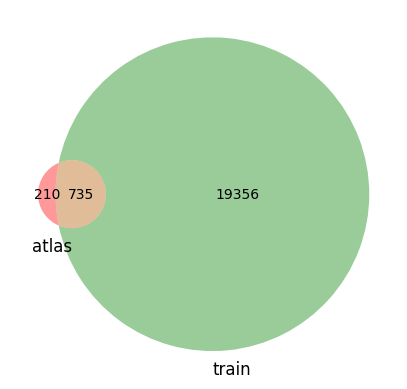

merged sc data and external test dataset with shape (gene, cell): (735, 1148)
Import data, cell number: 1148, gene number: 735
After cell threshold: 0, remain adata shape (cell, gene): (1148, 735)


/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/utils/utils_DandanProject.py:3258: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sc_expression_test_df[loss_gene_shortName_list] = 0
/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/utils/utils_DandanProject.py:3258: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sc_expression_test_df[loss_gene_shortName_list] = 0
/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/utils/utils_DandanProject.py:3258: PerformanceWarning: DataFrame is highly fragmented.  This is usua

remain test adata cell num 593
Finish normalize per cell, so that every cell has the same total count after normalization.
Finish normalize per gene as Gaussian-dist (0, 1).


2024-05-10 12:02:24,614 INFO - utils.utils_DandanProject - read the original sc expression anndata with shape (gene, cell): (945, 555) 
2024-05-10 12:02:24,615 INFO - utils.utils_DandanProject - Import data, cell number: 555, gene number: 945 
2024-05-10 12:02:24,641 INFO - utils.utils_DandanProject - After drop gene threshold: 50, cell threshold: 100, remain adata shape: (555, 945) 
2024-05-10 12:02:24,641 INFO - utils.utils_DandanProject - Drop cells with less than 100 gene expression, drop genes which none expression in 50 samples 
2024-05-10 12:02:24,641 INFO - utils.utils_DandanProject - After filter, get cell number: 555, gene number: 945 
2024-05-10 12:02:24,649 INFO - utils.utils_DandanProject - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2024-05-10 12:02:24,659 INFO - utils.utils_DandanProject - Finish normalize per gene as Gaussian-dist (0, 1). 
2024-05-10 12:02:24,660 INFO - utils.utils_DandanProject - Get express

Free Memory Percentage: 28.32%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 36.596GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 36.596GB


2024-05-10 12:02:26,200 INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /mnt/yijun/nfs_share/yijun_tmp/tmp8v6e_e1m 
2024-05-10 12:02:26,202 INFO - torch.distributed.nn.jit.instantiator - Writing /mnt/yijun/nfs_share/yijun_tmp/tmp8v6e_e1m/_remote_module_non_scriptable.py 
2024-05-10 12:02:26,459 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2024-05-10 12:02:26,460 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2024-05-10 12:02:26,461 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2024-05-10 12:02:26,461 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2024-05-10 12:02:26,461 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 
2024-05-10 12:02:27,351 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2024-05-11 01:02:27.935869: I tensorflow/core/plat

Predicting: 0it [00:00, ?it/s]

plot result save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500/
=== data correlation: 
Spearman correlation=0.84343, p-value=0.00000; 
Pearson correlation=0.73935, p-value=0.00000; 
Kendall correlation=0.68374, p-value=0.00000; 
R-squared=-0.14610.


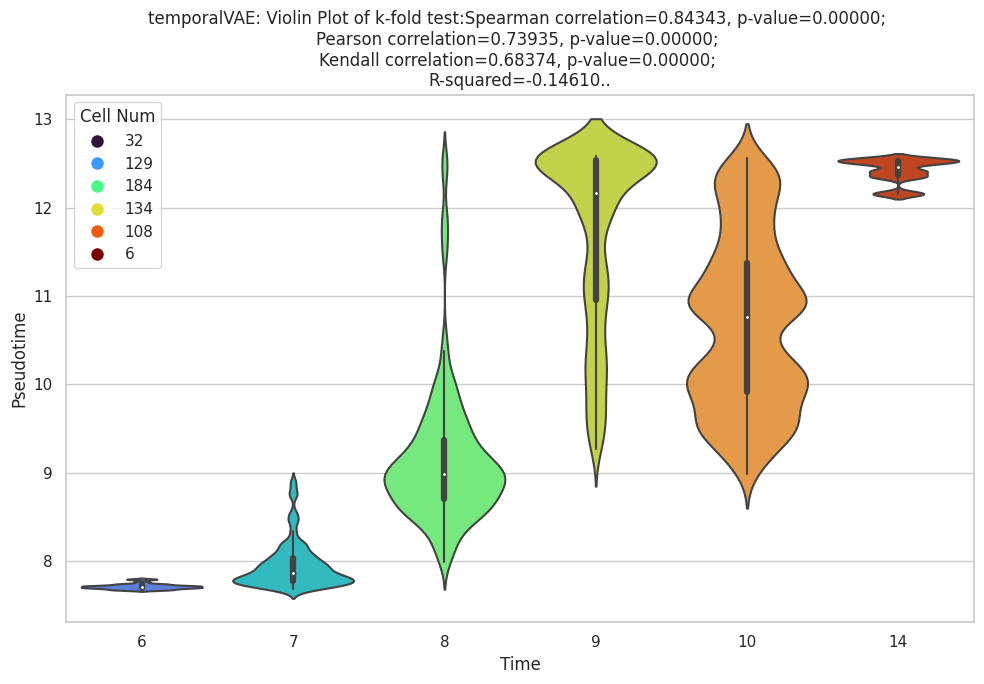

... storing 'Sample Type' as categorical
... storing 'Taxonomy' as categorical
... storing 'Platform_x' as categorical
... storing 'Series' as categorical
... storing 'Supplementary Types' as categorical
... storing 'Contact' as categorical
... storing 'Release Date' as categorical
... storing 'Assay Type' as categorical
... storing 'BioProject' as categorical
... storing 'Center Name' as categorical
... storing 'Consent' as categorical
... storing 'DATASTORE filetype' as categorical
... storing 'DATASTORE provider' as categorical
... storing 'DATASTORE region' as categorical
... storing 'development_day' as categorical
... storing 'Instrument' as categorical
... storing 'LibraryLayout' as categorical
... storing 'LibrarySelection' as categorical
... storing 'LibrarySource' as categorical
... storing 'Organism' as categorical
... storing 'Platform_y' as categorical
... storing 'ReleaseDate' as categorical
... storing 'create_date' as categorical
... storing 'source_name' as categorical

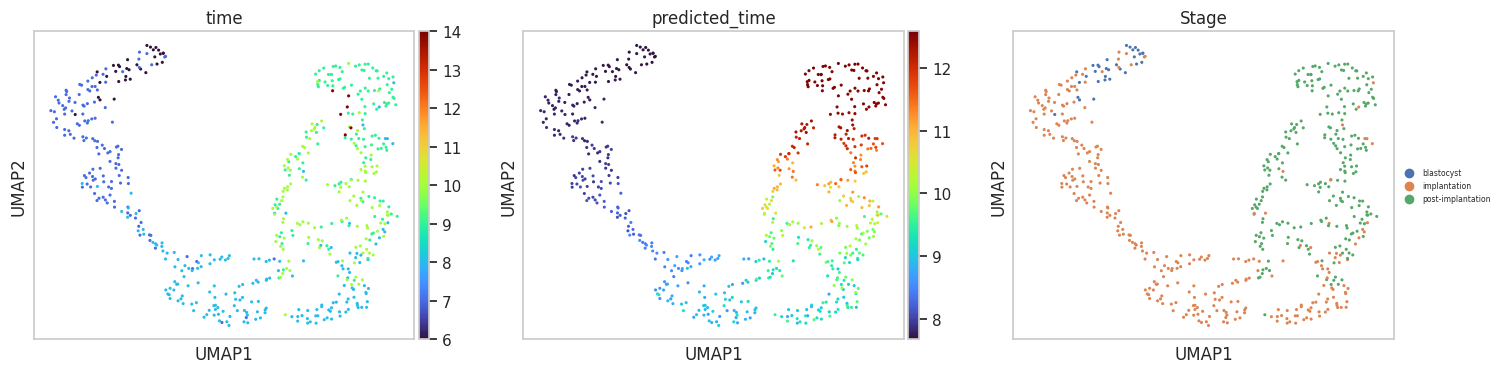

figure save as results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//latentSpace_umap_byScanpy.png
Final corr: Spearman correlation=0.84343, p-value=0.00000; 
Pearson correlation=0.73935, p-value=0.00000; 
Kendall correlation=0.68374, p-value=0.00000; 
R-squared=-0.90349.
test result save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//temporalVAE_result_df.csv


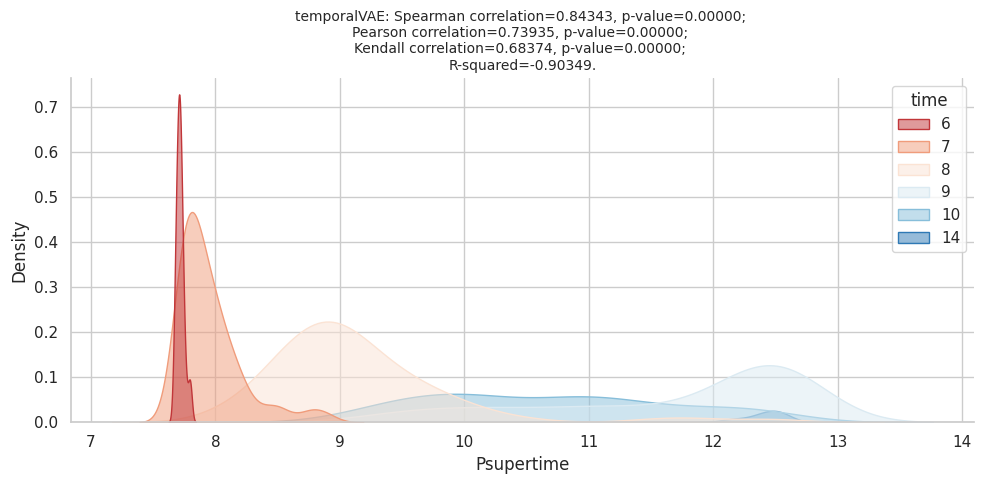

figure save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//temporalVAE_labelsOverPsupertime.png
Finish temporalVAE train on baseline data and predict on query data.
Final corr: Spearman correlation=0.78842, p-value=0.00000; 
Pearson correlation=0.71619, p-value=0.00000; 
Kendall correlation=0.62255, p-value=0.00000; 
R-squared=-2.19916.
test result save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//linearRegression_result_df.csv
=== data correlation: 
Spearman correlation=0.78842, p-value=0.00000; 
Pearson correlation=0.71619, p-value=0.00000; 
Kendall correlation=0.62255, p-value=0.00000; 
R-squared=-0.41720.


/mnt/yijun/nfs_share/yijun_tmp/ipykernel_2623881/1277131865.py:113: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)


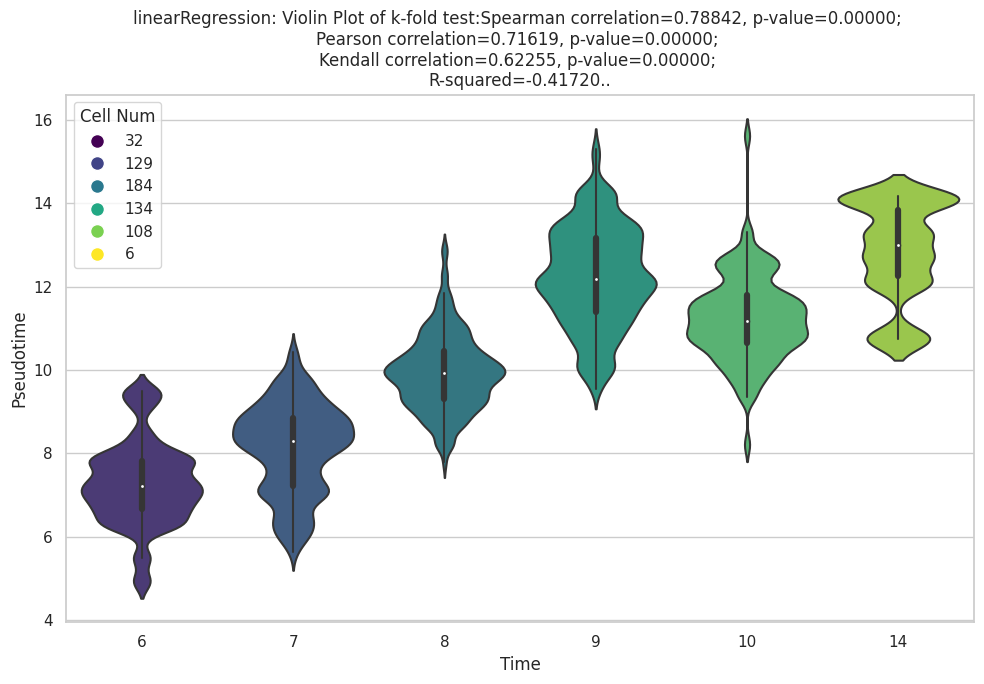

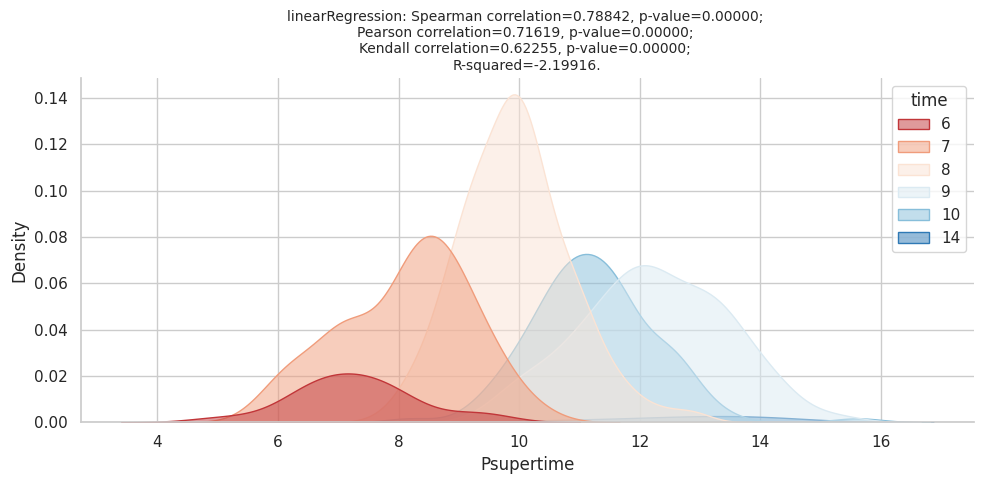

figure save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//linearRegression_labelsOverPsupertime.png
Finish linearRegression train on baseline data and predict on query data.
Final corr: Spearman correlation=0.62688, p-value=0.00000; 
Pearson correlation=0.62402, p-value=0.00000; 
Kendall correlation=0.48974, p-value=0.00000; 
R-squared=-47.67518.
test result save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//PCAresult_df.csv
=== data correlation: 
Spearman correlation=0.62688, p-value=0.00000; 
Pearson correlation=0.62402, p-value=0.00000; 
Kendall correlation=0.48974, p-value=0.00000; 
R-squared=-1.10707.


/mnt/yijun/nfs_share/yijun_tmp/ipykernel_2623881/1277131865.py:158: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)


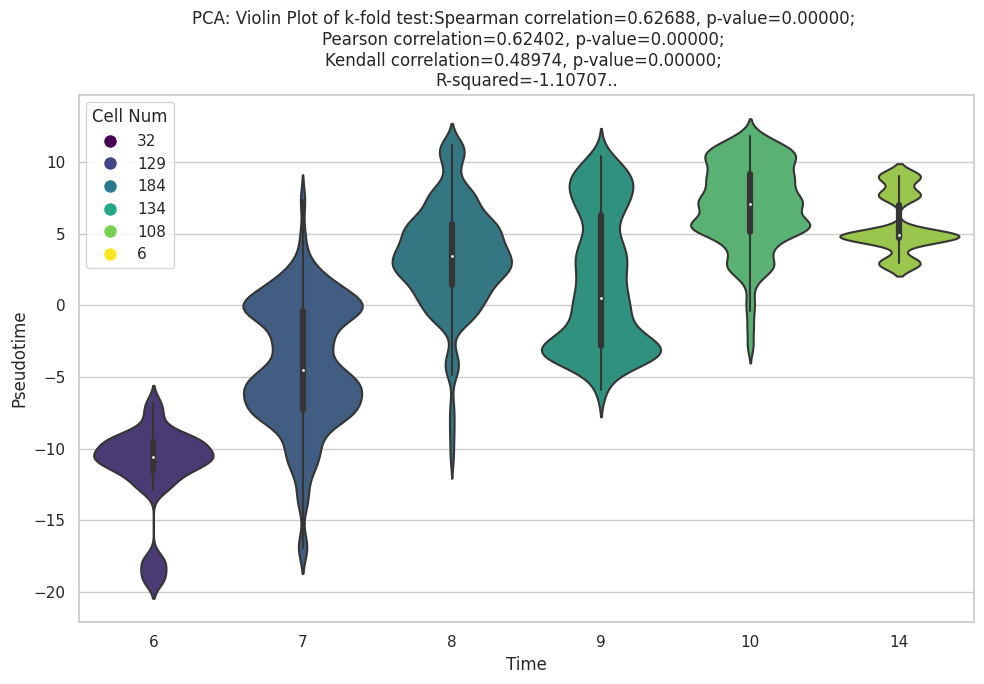

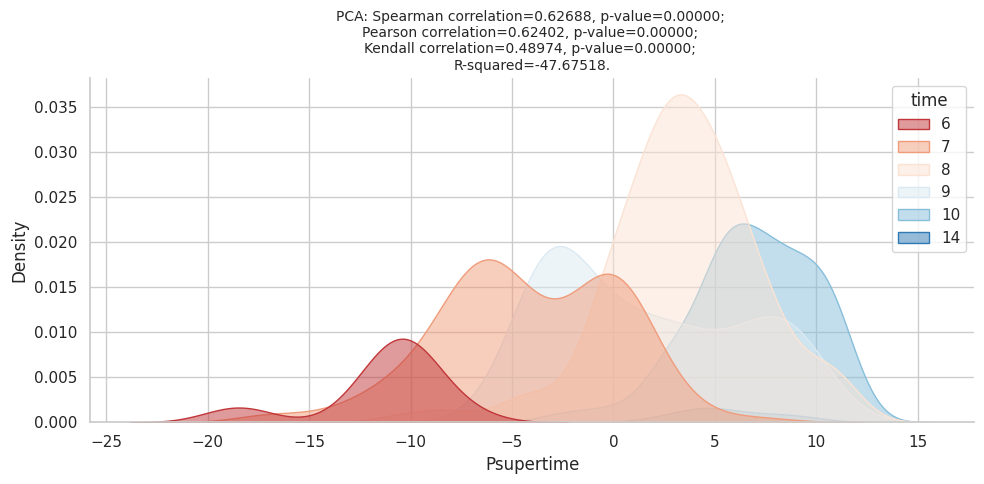

figure save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//PCA_labelsOverPsupertime.png
Finish PCA train on baseline data and predict on query data.


/mnt/yijun/nfs_share/yijun_tmp/ipykernel_2623881/1277131865.py:134: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)


Final corr: Spearman correlation=0.80485, p-value=0.00000; 
Pearson correlation=0.73007, p-value=0.00000; 
Kendall correlation=0.66074, p-value=0.00000; 
R-squared=-1.96513.
test result save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//randomForest_result_df.csv
=== data correlation: 
Spearman correlation=0.80485, p-value=0.00000; 
Pearson correlation=0.73007, p-value=0.00000; 
Kendall correlation=0.66074, p-value=0.00000; 
R-squared=-0.22393.


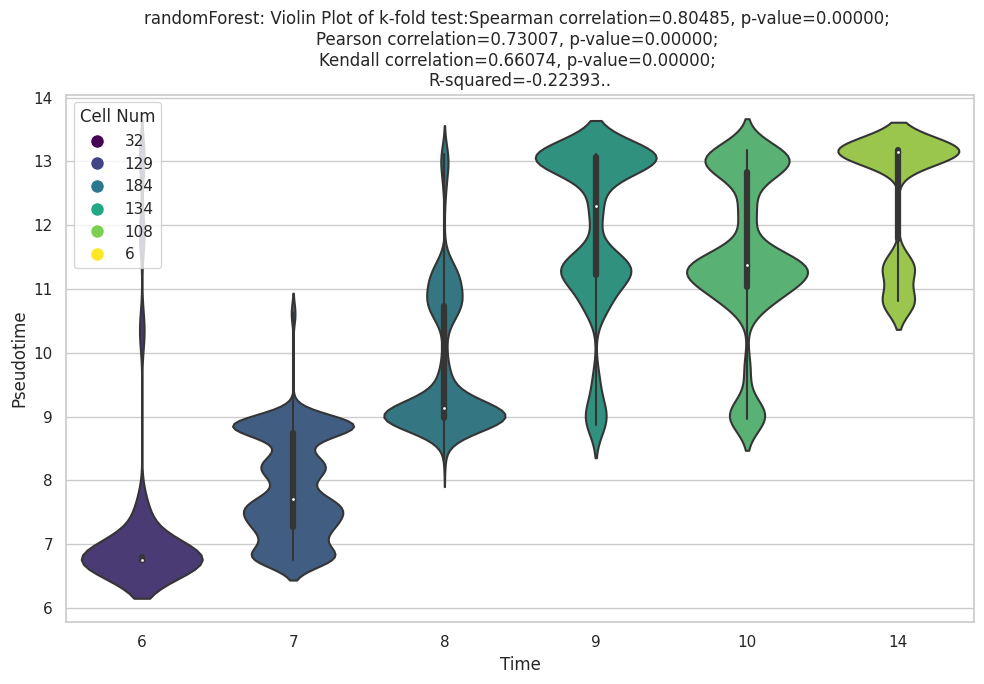

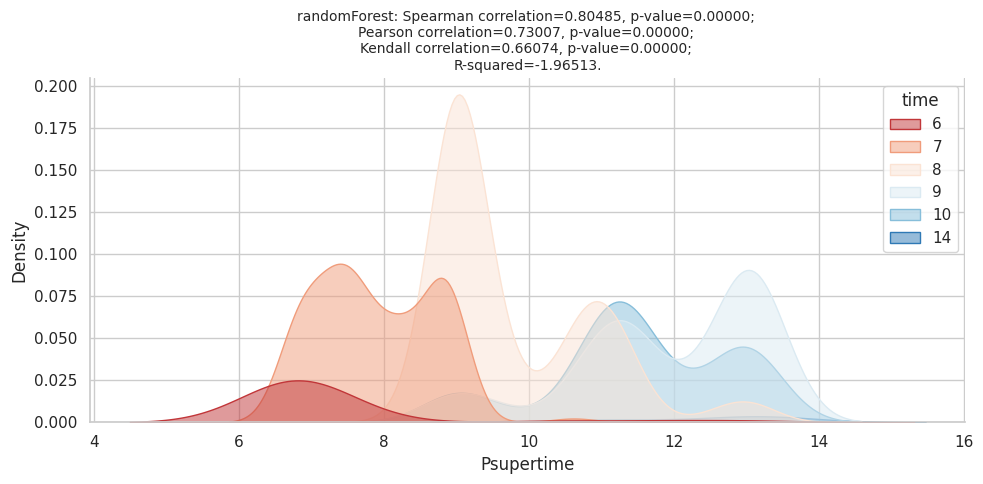

figure save at results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500//randomForest_labelsOverPsupertime.png
Finish randomForest train on baseline data and predict on query data.


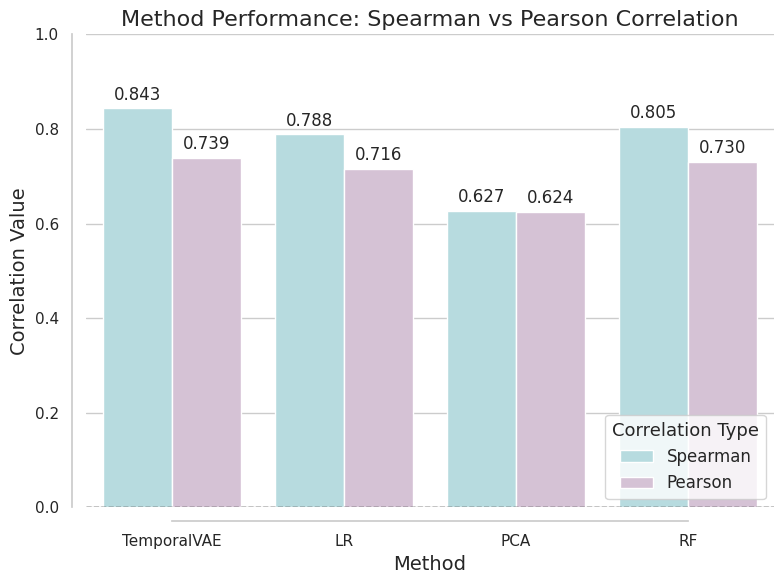

In [3]:
save_path = f"results/240510_Figure4_LR_PCA_RF_directlyPredictOn_humanEmbryo_PLOS_xiang19hvg500/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
data_golbal_path = "data/"
baseline_data_path = "/240322Human_embryo/xiang2019/hvg500/"
query_data_path = "/240322Human_embryo/PLOS2019/"
checkpoint_file = 'results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/checkpoints/last.ckpt'
config_file = f"vae_model_configs/supervise_vae_regressionclfdecoder_mouse_stereo.yaml"
# ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
logger_file = f'{save_path}/run.log'
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
_logger.info("Finished setting up the logger at: {}.".format(logger_file))
_logger.info(f"baseline dataset: {data_golbal_path}/{baseline_data_path}, \n and query dataset: {data_golbal_path}/{query_data_path}")
with open(config_file, 'r') as file:
    config = yaml.safe_load(file)
# ---------------------------------------------preprocess on query data-----------------------------------------------------------------------
gene_dic = geneId_geneName_dic()
try:
    adata_query = ad.read_csv(f"{data_golbal_path}/{query_data_path}/data_count_hvg.csv", delimiter='\t')
except:
    adata_query = ad.read_csv(f"{data_golbal_path}/{query_data_path}/data_count_hvg.csv", delimiter=',')
cell_time_query_pd = pd.read_csv(f"{data_golbal_path}/{query_data_path}/cell_with_time.csv", sep="\t", index_col=0)
adata_query = adata_query.copy().T
adata_query.obs = cell_time_query_pd
trainData_renormalized_df, loss_gene_shortName_list, train_cell_info_df = predict_newData_preprocess_df(gene_dic, adata_query,
                                                                                                        min_gene_num=0,
                                                                                                        mouse_atlas_file=f"{data_golbal_path}/{baseline_data_path}/data_count_hvg.csv",
                                                                                                        bool_change_geneID_to_geneShortName=False
                                                                                                        )
query_adata = ad.AnnData(X=trainData_renormalized_df, obs=train_cell_info_df)
# ---------------------------------------------preprocess on baseline data---------------------------------------------------------------------------
atlas_sc_expression_df, cell_time_atlas = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path,
                                                                                        f"{baseline_data_path}/data_count_hvg.csv",
                                                                                        f"{baseline_data_path}/cell_with_time.csv",
                                                                                        min_cell_num=50,
                                                                                        min_gene_num=100)

directly_predict_on_vae( query_adata, save_path, checkpoint_file, config)

train_LR_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path)
train_PCA_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path)
train_RF_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path)
plot_compare_corr_boxplot(save_path)
